In [9]:
import pypsa
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pickle
import pandas as pd
import matplotlib.colors as mplcolors
import matplotlib as mpl
import copy
from tqdm import tqdm
import sys

path = '/media/fkaiser/'

sys.path.append(path+'Code/power-system-split/power_system_split/')
import utils,visualisation

## Load solved PyPSA network

In [2]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

co2level = 0.50
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{co2level}-3H.nc')
network.determine_network_topology()

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/xarray/backends/plugins.py:61: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, car

In [3]:
# select a particular subnetwork for calculations (if the pypsa network has different ones)
# Otherwise you can choose None or -1
subnetwork_index = 0
snet = network.sub_networks['obj'][str(subnetwork_index)]

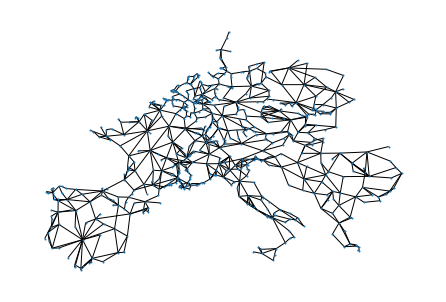

In [4]:
### build and plot network
G = utils.build_networkx_graph(network, snet_index = subnetwork_index)
pos = nx.get_node_attributes(G,'pos')
nx.draw(G,pos,node_size = 1)
plt.show()

## Example cascade run

In [5]:
month = 1
number_of_snapshots = 5

current_snapshots = network.snapshots[network.snapshots.month == month][:number_of_snapshots]
# line index is a unique number to identify the given edge and extracted directly from pypsa
indices = nx.get_edge_attributes(G,'line_index')
line_limits = nx.get_edge_attributes(G,'s_nom')

### iterate only over non-bridge edges for now
bridges = list(nx.bridges(nx.Graph(G)))
#multigraph_bridges = [bridges[i]+(0,) for i in range(len(bridges))]
#print(multigraph_bridges)

non_bridges = list(set(list(G.edges()))-set(bridges))

splitting_cascades = {}

for snapshot in tqdm(current_snapshots):

    splitting_cascades[snapshot.strftime('%d_%m_%Y_%H')] = []

    initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                       e, index_list in indices.items()}
    
    P0 = utils.get_effective_injections(G, initial_loading)

    l_copy = initial_loading.copy()
    for key in l_copy.keys():
        initial_loading[key[::-1]] = initial_loading[key]

    for edge in non_bridges:

        failing_links, system_split = utils.simulate_cascade_PTDF_based_edge_based_reduced(G,
                                                                                           trigger_links = [edge],
                                                                                           line_limits = line_limits,
                                                                                           P0 = P0)
        if system_split:
            splitting_cascades[snapshot.strftime('%d_%m_%Y_%H')].append(failing_links)
            
#with open(path+'Simulation_results/system_splits_%i.pickle'%ind, 'rb') as handle:
#    pickle.dump(splitting_cascades, handle, protocol = pickle.HIGHEST_PROTOCOL)

100%|██████████| 5/5 [01:02<00:00, 12.41s/it]


## Evaluate cascade results

In [6]:
# node criterion means that only split components with at least 10 nodes are evaluated
criterion = 'nodes'
use_pnom = True

solution_dict = {}

for key in tqdm(splitting_cascades.keys()):
    timestamp = utils.solution_key_to_pandas_timestamp(key)
    solution_dict[key] = []
    splits = splitting_cascades[key]
    for i,split in enumerate(splits):
        results = utils.evaluate_split_observables(split,
                                                   network,
                                                   timestamp,
                                                   use_pnom = use_pnom,
                                                   criterion = criterion,
                                                   snet_index = subnetwork_index)
        
        if results['inertia_proxy']:
            ### save the index of the split that was evaluated (i)
            ### and the results dict that contains the inertia proxy
            ### and the load imbalance for each split component that fulfills the criterion
            ### NOTE: to get the Rocof from load imbalance and the inertia proxy
            ### you need to multiply by a factor of 50Hz/(2*inertia_constant), where
            ### we typically set inertia_constant = 6s^{-1}
            solution_dict[key].append(i)
            solution_dict[key].append(results)

#with open(results_path + f'Europe_Co2L{co2l}_split_evaluation_' + criterion +f'_based_snet_{snet_index}_w_hvdc.pickle' , 'wb') as handle:
#    pickle.dump(solution_dict, handle, protocol = pickle.HIGHEST_PROTOCOL)


100%|██████████| 5/5 [01:16<00:00, 15.37s/it]


## Show examplary visualisation of failure probability

In [11]:
likelihood_primary, likelihood_secondary = visualisation.calc_likelihood_failure(G,
                                                            splitting_cascades,
                                                            number_of_snapshots,
                                                            solution_dict = solution_dict)

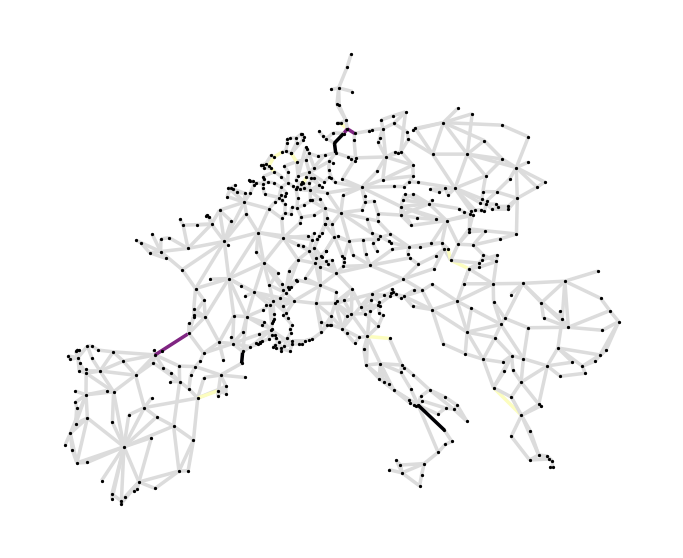

In [18]:
f,ax = plt.subplots(figsize = (12,10))
cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro',1.0)

likelihood = [likelihood_primary[(u,v)] for u,v in G.edges()]

edge_colors_log = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])

vmin = np.min(edge_colors_log[np.logical_and(~np.isnan(edge_colors_log),edge_colors_log!=-float("inf"))])
vmax = np.max(edge_colors_log[np.logical_and(~np.isnan(edge_colors_log),edge_colors_log!=-float("inf"))])

nodes = nx.draw_networkx_nodes(G, 
                               pos = pos,
                               ax = ax,
                               node_color = 'black',
                               node_size = 5)

edges = nx.draw_networkx_edges(G, 
                               pos = pos,
                               ax = ax, 
                               edge_color = edge_colors_log,
                               width = 3.5,
                               edge_cmap = cmap,
                               edge_vmin = vmin,
                               edge_vmax = vmax)

ax.axis('off')    
plt.show()